In [1]:
import pandas as pd

df = pd.read_csv("Adult_Census.csv")

df.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


In [2]:
df.shape

(32561, 15)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education.num   32561 non-null  int64 
 5   marital.status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital.gain    32561 non-null  int64 
 11  capital.loss    32561 non-null  int64 
 12  hours.per.week  32561 non-null  int64 
 13  native.country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


In [4]:
df['income'].value_counts()

income
<=50K    24720
>50K      7841
Name: count, dtype: int64

In [5]:
df = df.replace('?', pd.NA)

In [6]:
df.isna().sum()

age                  0
workclass         1836
fnlwgt               0
education            0
education.num        0
marital.status       0
occupation        1843
relationship         0
race                 0
sex                  0
capital.gain         0
capital.loss         0
hours.per.week       0
native.country     583
income               0
dtype: int64

In [7]:
df['workclass'].fillna(df['workclass'].mode()[0], inplace=True)
df['occupation'].fillna(df['occupation'].mode()[0], inplace=True)
df['native.country'].fillna(df['native.country'].mode()[0], inplace=True)

In [8]:
df.isna().sum()

age               0
workclass         0
fnlwgt            0
education         0
education.num     0
marital.status    0
occupation        0
relationship      0
race              0
sex               0
capital.gain      0
capital.loss      0
hours.per.week    0
native.country    0
income            0
dtype: int64

In [9]:
df = df.drop("fnlwgt", axis=1)

In [10]:
X = df.drop("income", axis=1)
y = df["income"]

In [11]:
X = pd.get_dummies(X, drop_first=True)

In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [13]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [14]:
X.shape

(32561, 96)

In [15]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [16]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, pred))
print("Precision:", precision_score(y_test, pred, pos_label='>50K'))
print("Recall:", recall_score(y_test, pred, pos_label='>50K'))
print("F1:", f1_score(y_test, pred, pos_label='>50K'))

Accuracy: 0.8522954091816367
Precision: 0.7382075471698113
Recall: 0.5988520408163265
F1: 0.6612676056338028


In [17]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=200, random_state=42)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, rf_pred))
print("Precision:", precision_score(y_test, rf_pred, pos_label='>50K'))
print("Recall:", recall_score(y_test, rf_pred, pos_label='>50K'))
print("F1:", f1_score(y_test, rf_pred, pos_label='>50K'))

Accuracy: 0.8436972209427299
Precision: 0.7016129032258065
Recall: 0.6103316326530612
F1: 0.6527967257844475


In [18]:
from sklearn.svm import SVC

svm = SVC(kernel='linear')

svm.fit(X_train, y_train)

svm_pred = svm.predict(X_test)

print("Accuracy:", accuracy_score(y_test, svm_pred))
print("Precision:", precision_score(y_test, svm_pred, pos_label='>50K'))
print("Recall:", recall_score(y_test, svm_pred, pos_label='>50K'))
print("F1:", f1_score(y_test, svm_pred, pos_label='>50K'))

Accuracy: 0.84692154153232
Precision: 0.7369294605809129
Recall: 0.5663265306122449
F1: 0.6404615939415795


Matplotlib is building the font cache; this may take a moment.


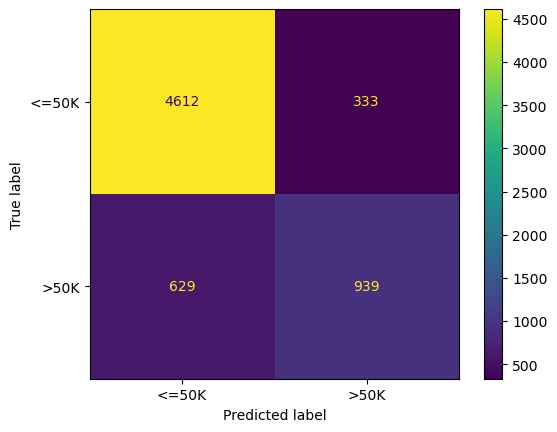

In [19]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, pred)

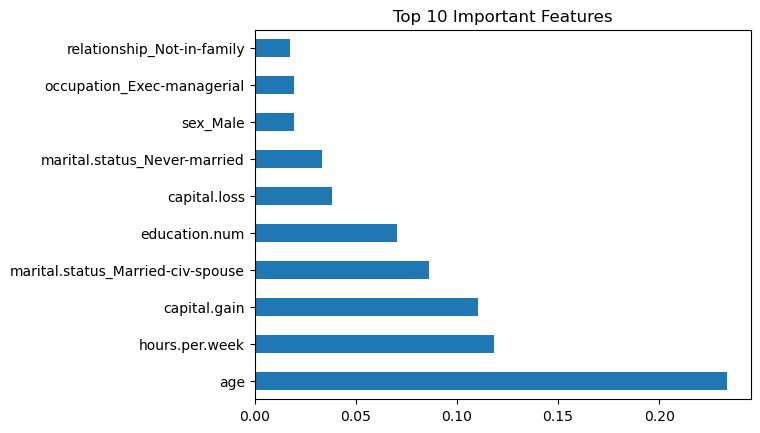

In [20]:
import pandas as pd
import matplotlib.pyplot as plt

importances = rf.feature_importances_

features = pd.Series(importances, index=X.columns)

top_features = features.sort_values(ascending=False).head(10)

top_features.plot(kind='barh')
plt.title("Top 10 Important Features")
plt.show()